# Frequency reconstruction and spectral recovery, Pagani *et al.* figures

**PATCHALIAS.** This notebook produces **two kinds of figure and nothing else**, on the
pure-sinusoid sweep of Deliverable~1's Data section:

1. **Reconstruction**, input frequency against the dominant frequency the model actually generates,
   with the ideal diagonal. Where the curve leaves the diagonal, the model is rebuilding the wrong
   frequency.
2. **Spectral recovery map**, a red-to-green strip along the spectrum saying where the frequency is
   still readable from the model's representation and where it is not. Pagani *et al.* read this in
   three states; here the scale between them is **continuous**, so a band that degrades gradually
   reads as a gradient rather than as a staircase. The old thresholds survive as the colour
   anchors: $0.5$ is chance, $0.6$ still carries the "lost" red and $0.9$ the "recovered" green.

Every figure is written to disk, one file per figure: the pair per geometry, each panel of that
pair on its own so either can be used as a standalone figure, and the two cross-geometry summaries.
The final cell prints the manifest of what was written.

It is deliberately separate from `bayesian_analysis.ipynb` and self-contained: every figure is
built here from `probe_lib`, so nothing depends on the older notebooks in `chronos/testing/`.
Signals are **pure sinusoids** ($2$–$250$ Hz), which is the first analysis of Deliverable~1; the
generator backgrounds belong to the Bayesian part.

Frequencies are drawn in the dimensionless units of Section 2, as in `appendix_reconstruction.ipynb`:
cycles per patch, `cpp = f P / fs`, on the main axis and cycles per stride, `cps = f S / fs`,
on the secondary one, each panel in its own geometry. Measurements and stored tables stay in Hz.
Patch-branch sites (integer cpp) and stride-branch sites (integer cps) are drawn with different dashes.

Outputs go next to the Bayesian run, in `_run/full/pagani/`.


## 0, Setup

In [1]:
import importlib.util, subprocess, sys

REQUIRED = {"torch": "torch", "chronos": "chronos-forecasting",
            "sklearn": "scikit-learn", "pyarrow": "pyarrow"}
missing = [pip for mod, pip in REQUIRED.items() if importlib.util.find_spec(mod) is None]
if missing:
    print("installing:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
else:
    print("nothing to install")

nothing to install


In [2]:
import os, sys
from pathlib import Path

REPO_URL = "https://github.com/FedericoSabbadini/patchAliasing.git"
MARKER   = Path("notebooks") / "support_scripts" / "probe_lib.py"

def find_repo() -> Path:
    """Locate the repository root by walking up from the current working directory."""
    here = Path.cwd()
    for cand in [here, *here.parents]:
        if (cand / MARKER).exists():
            return cand

    # If not found locally, clone the repository
    import subprocess
    target = here / "patchAliasing"
    if not (target / ".git").exists():
        subprocess.check_call(["git", "clone", "--depth", "1", REPO_URL, str(target)])
    if not (target / MARKER).exists():
        raise FileNotFoundError(f"{MARKER} missing from {target}; push it or upload it by hand.")
    return target

REPO = find_repo()
sys.path.insert(0, str(REPO / "notebooks" / "support_scripts"))

# Evict cached module objects so a kernel restart is not needed after a git pull
for _m in ("probe_lib", "testing_lib"):
    sys.modules.pop(_m, None)

print("repository:", REPO)

repository: c:\Users\bonio\dev\patchAliasing


In [3]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict, StratifiedKFold

warnings.filterwarnings("ignore")
import probe_lib as pl

SEED = pl.SEED
np.random.seed(SEED)

# ---- what to run ----------------------------------------------------------------------
# Every geometry of the published sweep. All are retrained checkpoints under the same budget.
GEOMETRIES = pl.MODELS
#GEOMETRIES = [(16,16)]

# ---- Pagani parity --------------------------------------------------------------------
# These four numbers are the ones that make this notebook a reproduction of Pagani et al.
# rather than a second, slightly different experiment, and each of them matters:
#
#   context   the longest L <= 512 that the patch grid covers exactly (L % P == 0 and
#             (L - P) % S == 0): 512 on nine geometries, 504 on the five with P = 24 and 496
#             on p16-s12. Pagani et al. shortened ~512 to a multiple of the stride, which left
#             masked padding or uncovered samples on seven geometries; see `pagani_context`.
#   GEN_LEN   512 -> the rollout DFT has 1 Hz bins. At 256 the bins are 2 Hz wide and the
#             reconstruction curve is quantised to twice the step.
#   N_PHASE   10 phases per frequency for the probe, 4 for the rollout, as in the paper.
FREQ_STEP   = 1           # sweep step [Hz]; 1 Hz is the grid Deliverable 1 specifies
N_PHASE     = 10          # phases per frequency (probing dataset)
GEN_LEN     = 512         # autoregressive rollout length
N_PHASE_GEN = 4           # phases per frequency (rollout)
BATCH       = 64

def pagani_context(P: int, S: int, target: int = 512) -> int:
    """Context length of the sweep: the longest L <= 512 that the patch grid covers exactly.

    Chronos-Bolt (chronos_bolt.Patch) left-pads the context with masked values up to a multiple of P
    and then cuts a patch every S samples with `unfold`, so the (L' - P) mod S most recent samples of
    the padded length L' enter no token. Requiring L % P == 0 and (L - P) % S == 0 removes both
    effects: nothing is padded and every sample enters at least one token (`token_coverage`
    reports exact=True for every geometry). The earlier rule, the longest multiple of S, left
    padding or uncovered samples on seven geometries (p16-s12, p24-s8, p24-s16, p24-s20, p32-s12,
    p32-s20, p32-s24); those seven now run at L = 496, 504 or 512 and must be re-measured.
    Only L = 512 holds a whole number of cycles of every integer tone; at L = 496 and 504 integer
    tones leak, identically for every frequency of that geometry.
    """
    for L in range(target - target % P, P - 1, -P):
        if (L - P) % S == 0:
            return L
    raise ValueError(f"no exact context <= {target} for P={P}, S={S}")


def token_coverage(L: int, P: int, S: int) -> dict:
    """What Chronos-Bolt's patching does to a context of L samples.

    left_pad        masked values prepended so that the length is a multiple of P
    tokens          patches cut every S samples from the padded length L'
    left_out        most recent samples after the last complete patch: (L' - P) mod S
    exact           True when nothing is padded and nothing is left out, i.e. L % P == 0
                    and (L - P) % S == 0
    """
    pad = (-L) % P
    Lp = L + pad
    return dict(P=P, S=S, context=L, left_pad=pad, tokens=(Lp - P) // S + 1,
                left_out=(Lp - P) % S, exact=(pad == 0 and (Lp - P) % S == 0))

# ---- output directory ------------------------------------------------------------------
CLEAN_OUTPUT = True       # False -> keep whatever is there and overwrite file by file
ARCHIVE_OLD  = True       # True -> move the previous run aside instead of deleting it

import shutil
_root = REPO / "notebooks" / "_run"
OUT = _root / "full" / "pagani"

if CLEAN_OUTPUT and OUT.exists() and any(OUT.iterdir()):
    if ARCHIVE_OLD:
        n = 1
        while (dest := OUT.with_name(f"pagani_prev{n:02d}")).exists():
            n += 1
        shutil.move(str(OUT), str(dest))
        print(f"previous run archived -> {dest}")
    else:
        shutil.rmtree(OUT)
        print(f"previous run deleted  -> {OUT}")
OUT.mkdir(parents=True, exist_ok=True)
assert not any(OUT.iterdir()), f"{OUT} is not empty; nothing was run"

FREQS = np.arange(pl.BAND[0], pl.BAND[1] + 1e-9, FREQ_STEP)
print(f"FULL | {len(GEOMETRIES)} geometries | "
      f"{len(FREQS)} frequencies x up to {N_PHASE} phases | rollout {GEN_LEN} samples")
print(f"figures and tables -> {OUT}")

previous run archived -> c:\Users\bonio\dev\patchAliasing\notebooks\_run\full\pagani_prev01
FULL | 15 geometries | 249 frequencies x up to 10 phases | rollout 512 samples
figures and tables -> c:\Users\bonio\dev\patchAliasing\notebooks\_run\full\pagani


## 1, Measurement

Two quantities per geometry, both on pure sinusoids.

**Reconstruction.** The model is given a sinusoid, its median forecast is fed back into the context,
and the rollout continues to `GEN_LEN` samples. The **dominant** frequency of the output is read off
as `argmax |DFT|` and compared with the frequency that went in. On the diagonal the tone survives;
a flat segment means a range of inputs collapses onto one output, and a jump means the model
rebuilds a tone that was never there.

**Spectral recovery.** A linear probe is trained on the $256$-d $[\mathrm{REG}]$ vector at the
projected head, where the paper localises the compression drop, and its cross-validated accuracy
is mapped along the spectrum. This asks something more basic than the rollout: is the frequency
still *present* in the representation, whatever the forecast then does with it?

Two probing tasks are computed. The **seven band tasks** are the paper's, each asking whether a tone
falls in the lower or upper half of its band; they carry a known artefact, since a task is genuinely
ambiguous *at its own decision boundary*, which is why the project's earlier testing notebook
dropped this figure. The **local discrimination** task has no such artefact: at each frequency it
asks one question of constant difficulty, can the probe separate $f-\Delta$ from $f+\Delta$?, so
every column is comparable. That is the row to trust, and the one used for the cross-model
comparison.

In [4]:
STAGE = "output_head"          # the paper's h4: the projected quantile head
DELTA_BINS = 1                 # local task compares neighbours, so delta = DELTA_BINS * FREQ_STEP


def probe_accuracy(X, y, groups=None, seed=SEED):
    """Cross-validated per-example correctness of a linear probe.

    `groups` is what separates the two tasks below, and it is not a detail.

    Band tasks: the classes are two HALVES OF A BAND, each containing many frequencies, so a probe
    that memorises individual frequencies can score well without ever learning the band boundary.
    Folds are therefore grouped by frequency (StratifiedGroupKFold): every phase of a held-out
    frequency is excluded from training, and the probe has to generalise the boundary. This is what
    chronos/testing/chronosBolt_layer_probing.ipynb does for its Fig. 4; an ungrouped split
    inflates these rows.

    Local task: the two classes ARE two frequencies, f-delta and f+delta, so grouping by frequency
    would put each class entirely in one fold and is impossible. A plain stratified split is the
    correct one here: it holds out phases, which is exactly the generalisation being asked about.
    """
    from sklearn.model_selection import StratifiedGroupKFold
    if len(np.unique(y)) < 2:
        return None
    if groups is None:
        n_splits = int(min(5, np.bincount(y).min()))
        cv = StratifiedKFold(n_splits, shuffle=True, random_state=seed) if n_splits >= 2 else None
    else:
        n0 = len(np.unique(groups[y == 0])); n1 = len(np.unique(groups[y == 1]))
        n_splits = int(min(5, n0, n1))
        cv = StratifiedGroupKFold(n_splits=n_splits, shuffle=True,
                                  random_state=seed) if n_splits >= 2 else None
    if cv is None:
        return None
    train_min = len(y) - int(np.ceil(len(y) / n_splits))
    n_comp = max(2, min(20, X.shape[1], train_min - 1))
    clf = make_pipeline(StandardScaler(), PCA(n_components=n_comp),
                        LogisticRegression(max_iter=2000))
    yhat = cross_val_predict(clf, X, y, cv=cv, groups=groups)
    return (yhat == y).astype(float)


def rollout_dominant(probe, freqs, n_phase, ctx_len):
    """Dominant output frequency after an autoregressive rollout, averaged over phases.

    All (frequency, phase) pairs advance in lockstep, so each rollout step is one batched forward
    pass rather than one per signal.
    """
    items = [(f, ph) for f in freqs for ph in pl.phases_Sf(f, n_phase)]
    ctx = np.stack([pl.build_context(None, f, ph, ctx_len) for f, ph in items])   # pure sinusoids
    gen = np.zeros((len(items), 0), dtype=np.float32)
    while gen.shape[1] < GEN_LEN:
        step = probe.forecast(ctx)
        gen = np.concatenate([gen, step], axis=1)
        ctx = np.concatenate([ctx, step], axis=1)[:, -ctx_len:]                   # slide the window
    gen = gen[:, :GEN_LEN]
    x = gen - gen.mean(axis=1, keepdims=True)          # remove DC before reading the peak
    mag = np.abs(np.fft.rfft(x, axis=1))
    fr = np.fft.rfftfreq(GEN_LEN, d=1 / pl.FS)
    dom = fr[np.argmax(mag[:, 1:], axis=1) + 1]        # and skip the DC bin outright
    out = pd.DataFrame(items, columns=["freq", "phase"])
    out["dominant"] = dom
    return out.groupby("freq")["dominant"].agg(["mean", "std"]).reset_index()


def spectral_accuracy(probe, freqs, n_phase, ctx_len):
    """Per-frequency probe accuracy: the seven band tasks, plus the local f+/-delta task."""
    items = [(f, ph) for f in freqs for ph in pl.phases_Sf(f, n_phase)]
    ctx = np.stack([pl.build_context(None, f, ph, ctx_len) for f, ph in items])
    feats = probe.capture_reg(ctx)[STAGE]
    lab_f = np.array([f for f, _ in items])

    rows, labels = [], []
    for (name, lo, hi, bnd) in pl.BAND_TASKS:
        m = (lab_f >= lo) & (lab_f <= hi)
        fm = lab_f[m]
        ok = probe_accuracy(feats[m], (fm > bnd).astype(int), groups=fm)   # grouped by frequency
        a = np.full(len(freqs), np.nan)
        if ok is not None:
            for ci, f in enumerate(freqs):
                sel = fm == f
                if sel.any():
                    a[ci] = ok[sel].mean()
        rows.append(a); labels.append(f"band task {name}")

    local = np.full(len(freqs), np.nan)
    for ci in range(DELTA_BINS, len(freqs) - DELTA_BINS):
        m = np.isin(lab_f, [freqs[ci - DELTA_BINS], freqs[ci + DELTA_BINS]])
        ok = probe_accuracy(feats[m], (lab_f[m] == freqs[ci + DELTA_BINS]).astype(int))
        if ok is not None:
            local[ci] = ok.mean()
    rows.append(local); labels.append(f"local $f\\pm{DELTA_BINS * FREQ_STEP:g}$ Hz")
    return np.vstack(rows), labels


In [5]:
# One geometry at a time: load, measure, free. This keeps memory usage bounded even
# with many geometries.
RESULTS = {}
for (P, S) in GEOMETRIES:
    ctx_len = pagani_context(P, S)
    probe = pl.Probe(P, S, device="cpu", batch_size=BATCH)
    print(f"\n=== {probe.label}  (P={probe.P}, S={probe.S}, context={ctx_len}) ===", flush=True)
    try:
        recon = rollout_dominant(probe, FREQS, N_PHASE_GEN, ctx_len)
        acc, row_labels = spectral_accuracy(probe, FREQS, N_PHASE, ctx_len)
        RESULTS[probe.tag] = dict(P=probe.P, S=probe.S, label=probe.label, ctx=ctx_len,
                                  recon=recon, acc=acc, row_labels=row_labels)
        rmse = float(np.sqrt(np.mean((recon["mean"] - recon["freq"]) ** 2)))
        good = np.nanmean(acc[-1] >= 0.9) * 100
        print(f"    spectral RMSE {rmse:6.1f} Hz | local task: {good:.0f}% of the band recovered")
    finally:
        probe.close()

# archive the numbers next to the figures, in this notebook's own directory; the context
# length is part of the name, so appendix_reconstruction.ipynb never reuses a result measured
# under a different context
for tag, r in RESULTS.items():
    r["recon"].to_parquet(OUT / f"recon_{tag}_L{r['ctx']}.parquet", index=False)
    pd.DataFrame(r["acc"].T, columns=r["row_labels"], index=FREQS).rename_axis("freq_hz") \
      .to_parquet(OUT / f"spectral_accuracy_{tag}_L{r['ctx']}.parquet")
print(f"\nmeasured {len(RESULTS)} geometries")

# How the context of each geometry is tokenised (Appendix F, table sweepContext).
COVERAGE = pd.DataFrame([token_coverage(pagani_context(P, S), P, S) for (P, S) in GEOMETRIES])
COVERAGE.to_csv(OUT / "context_coverage.csv", index=False)
print(COVERAGE.to_string(index=False))


=== p8-s8 (HF p8-s8-seed42)  (P=8, S=8, context=512) ===
    spectral RMSE  137.7 Hz | local task: 85% of the band recovered

=== p16-s8 (HF p16-s8-seed42)  (P=16, S=8, context=512) ===
    spectral RMSE  133.8 Hz | local task: 90% of the band recovered

=== p16-s12 (HF p16-s12-seed42)  (P=16, S=12, context=496) ===
    spectral RMSE  135.6 Hz | local task: 88% of the band recovered

=== p16-s16 (HF p16-s16-seed42)  (P=16, S=16, context=512) ===
    spectral RMSE  139.8 Hz | local task: 80% of the band recovered

=== p24-s8 (HF p24-s8-seed42)  (P=24, S=8, context=504) ===
    spectral RMSE  131.1 Hz | local task: 85% of the band recovered

=== p24-s12 (HF p24-s12-seed42)  (P=24, S=12, context=504) ===
    spectral RMSE  129.2 Hz | local task: 85% of the band recovered

=== p24-s16 (HF p24-s16-seed42)  (P=24, S=16, context=504) ===
    spectral RMSE  138.3 Hz | local task: 82% of the band recovered

=== p24-s20 (HF p24-s20-seed42)  (P=24, S=20, context=504) ===
    spectral RMSE  133.3

## 2, Per-geometry figures

Three files per geometry: the two panels side by side, and then each panel again on its own, so a
single panel can go into the deliverable without cropping the pair. Every frequency axis is in
cycles per patch (bottom, and left for the generated frequency) and cycles per stride (top, and right).


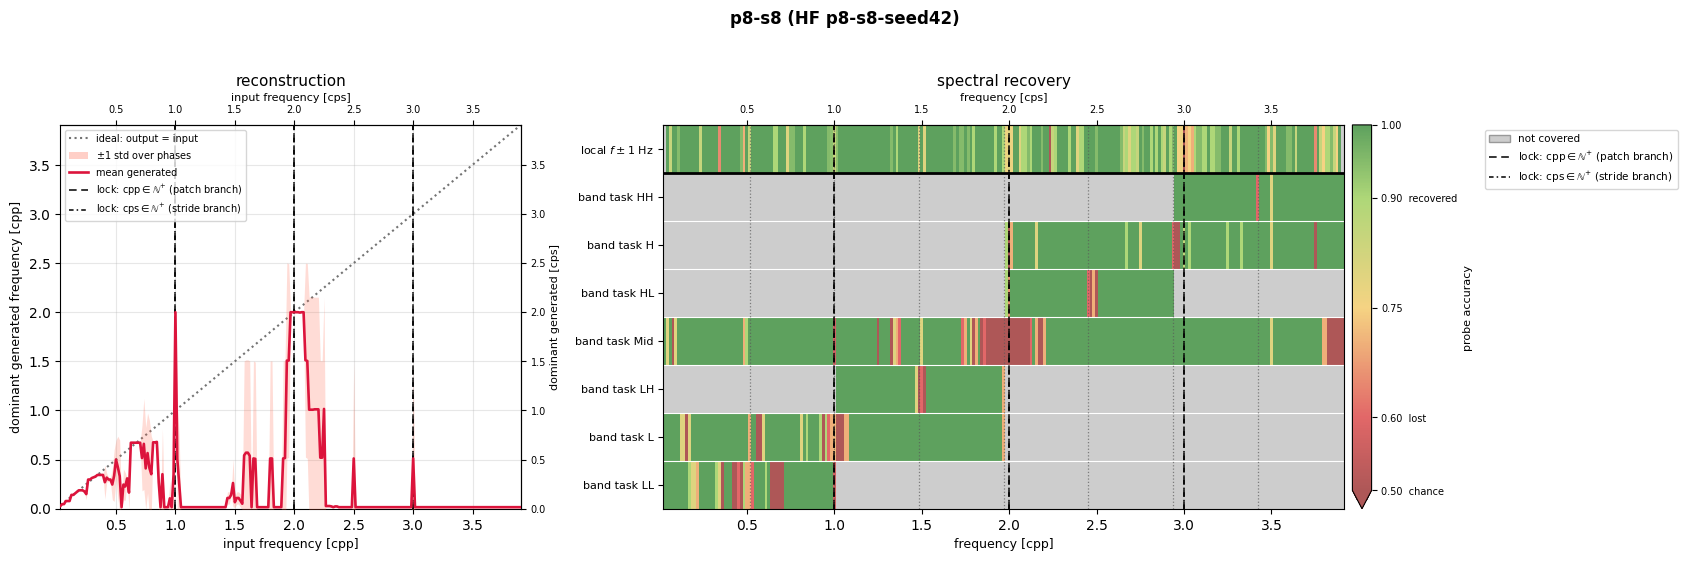

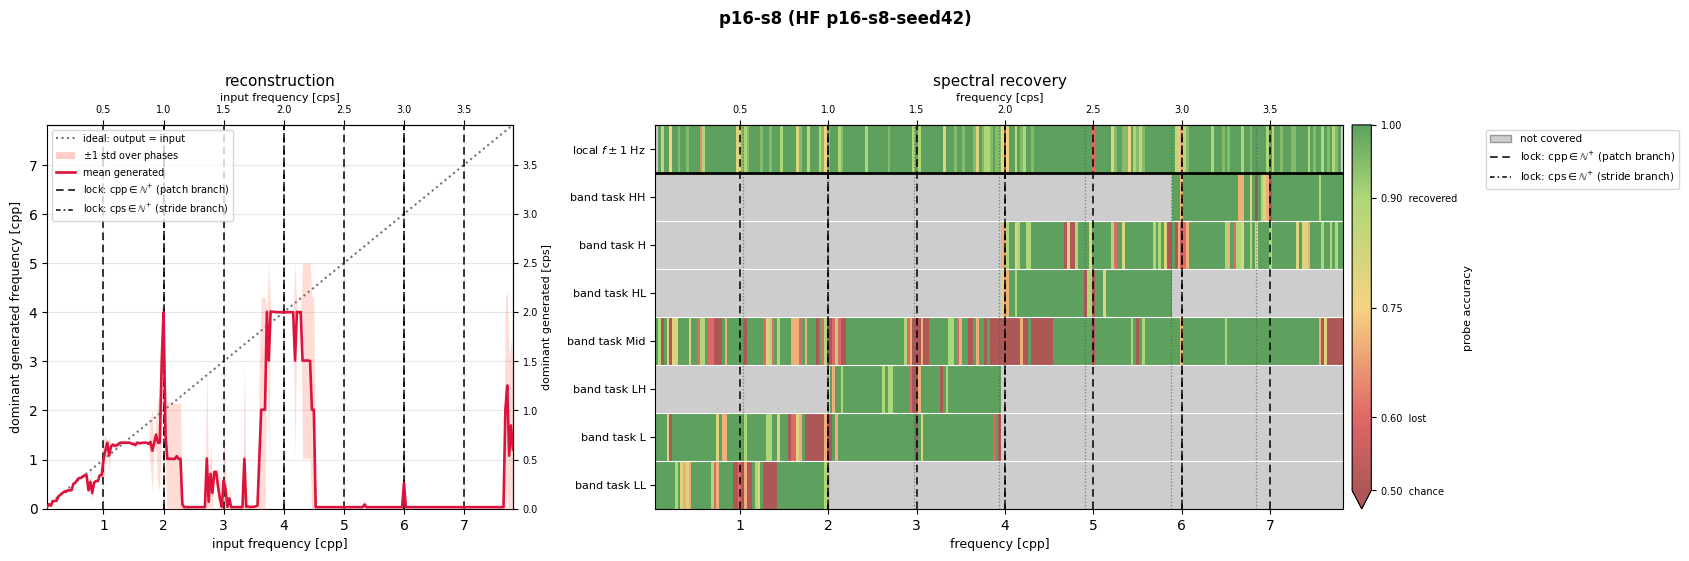

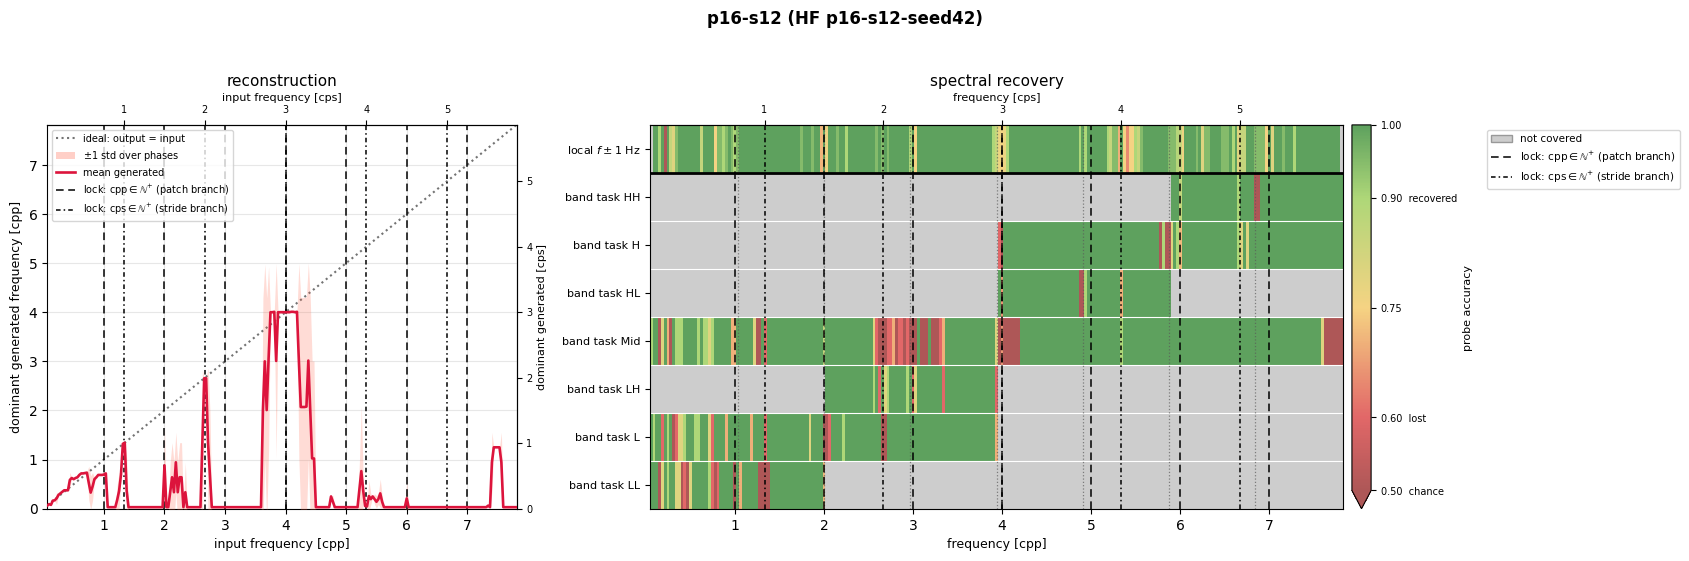

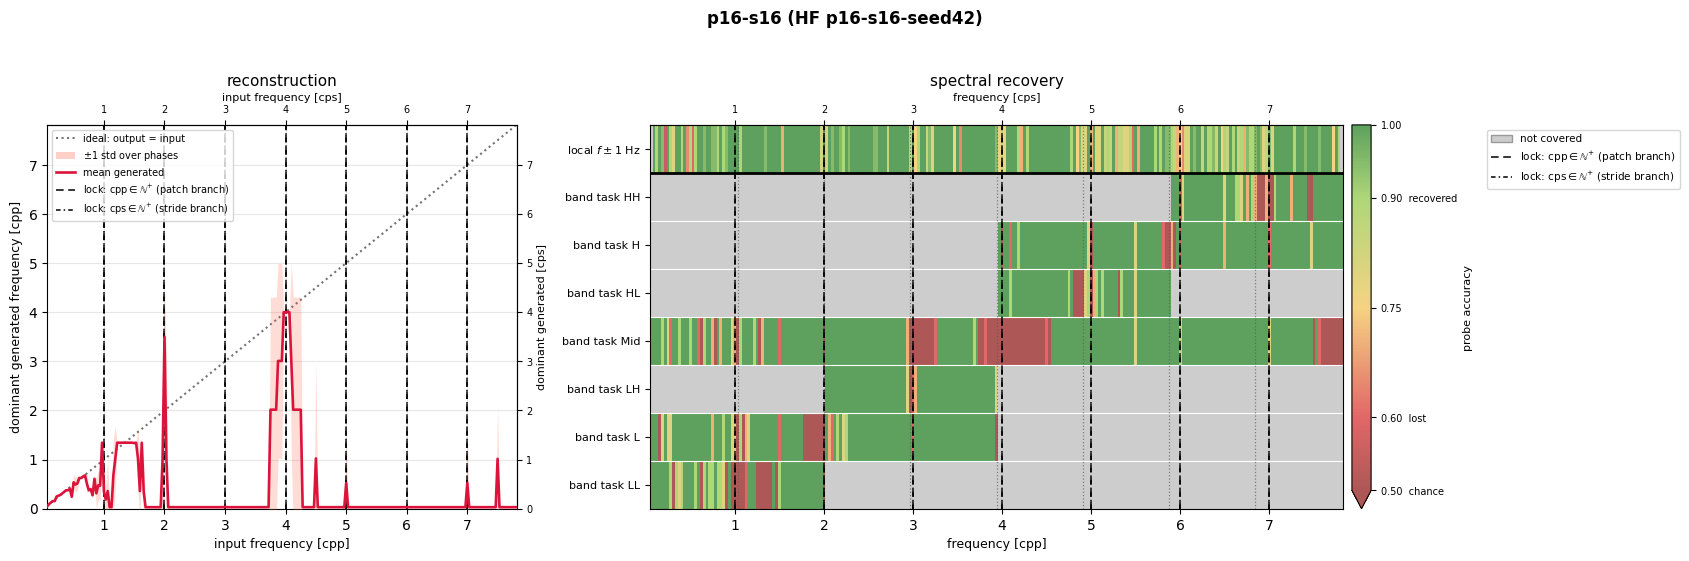

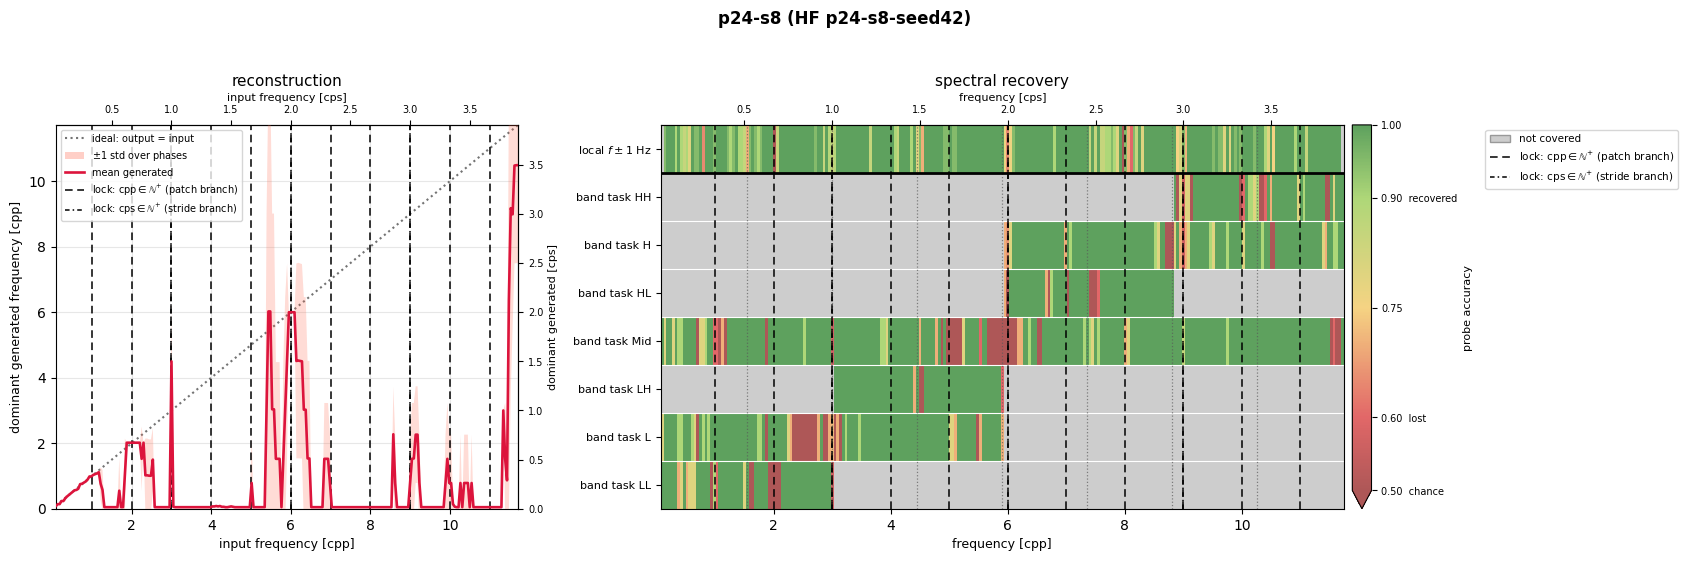

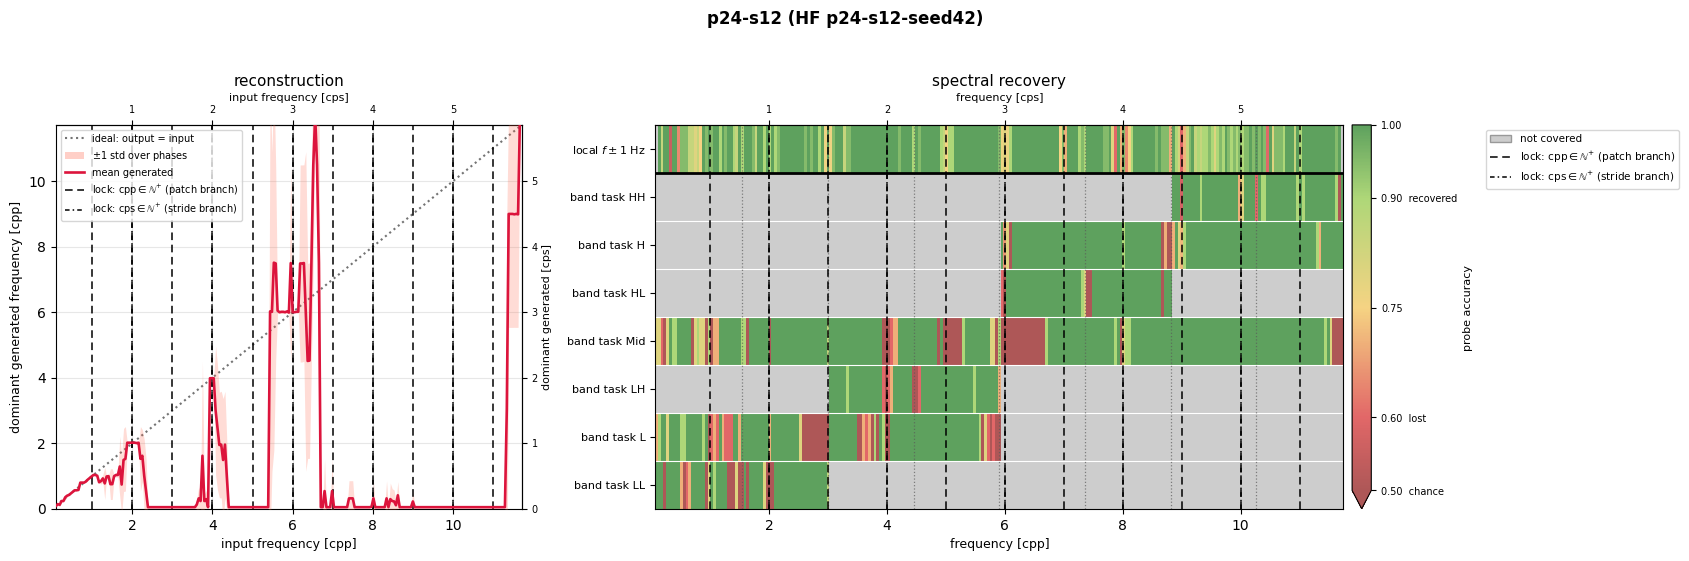

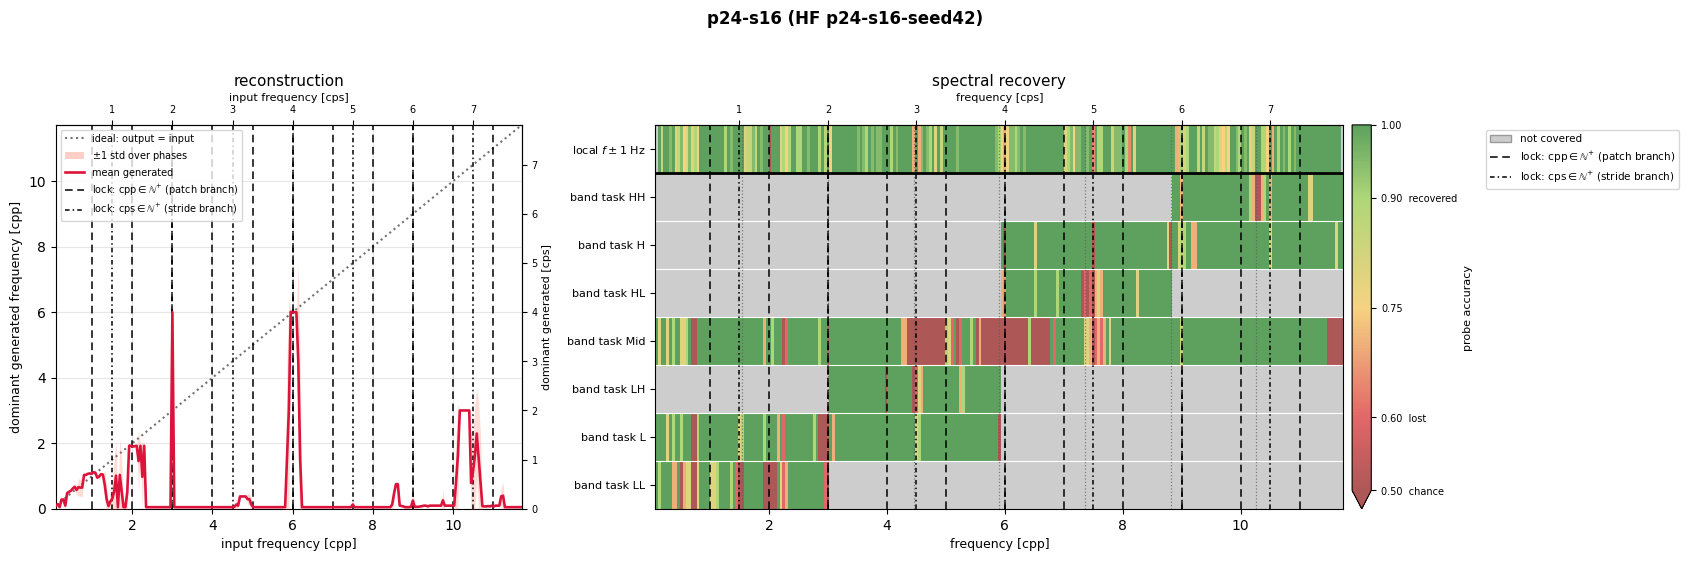

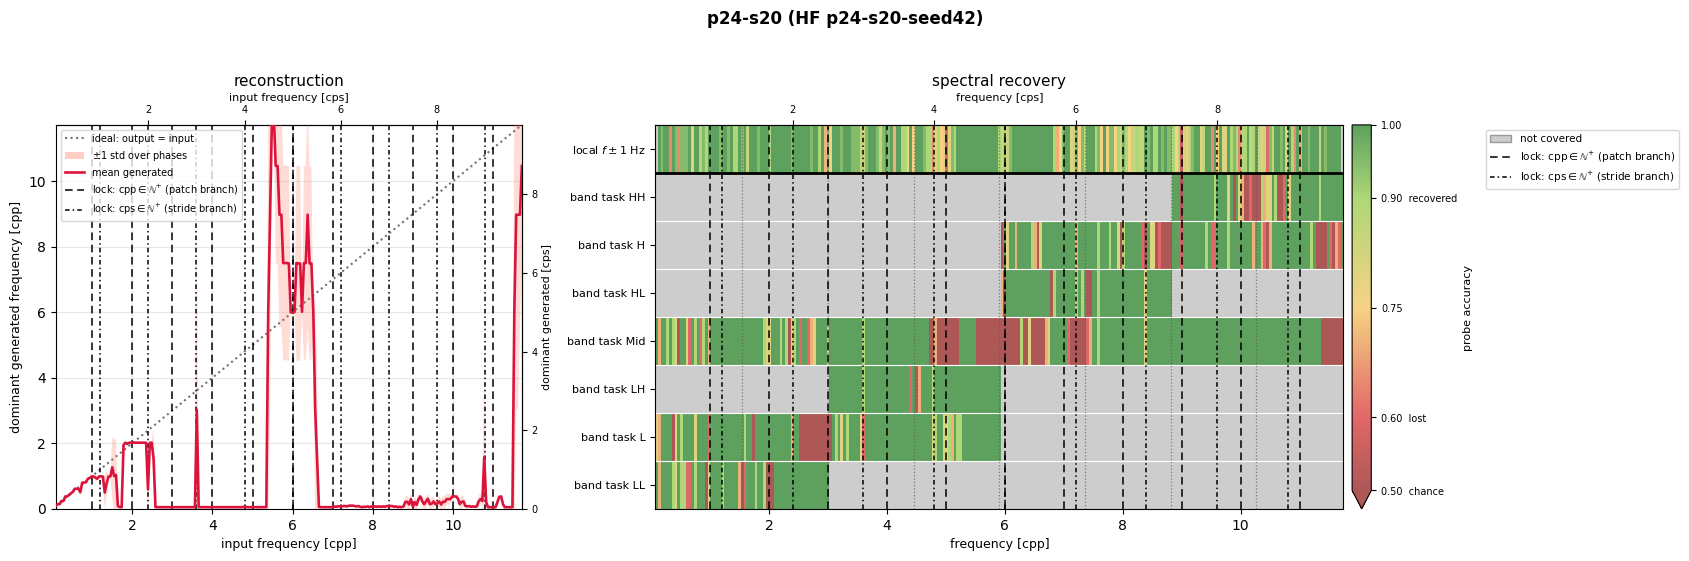

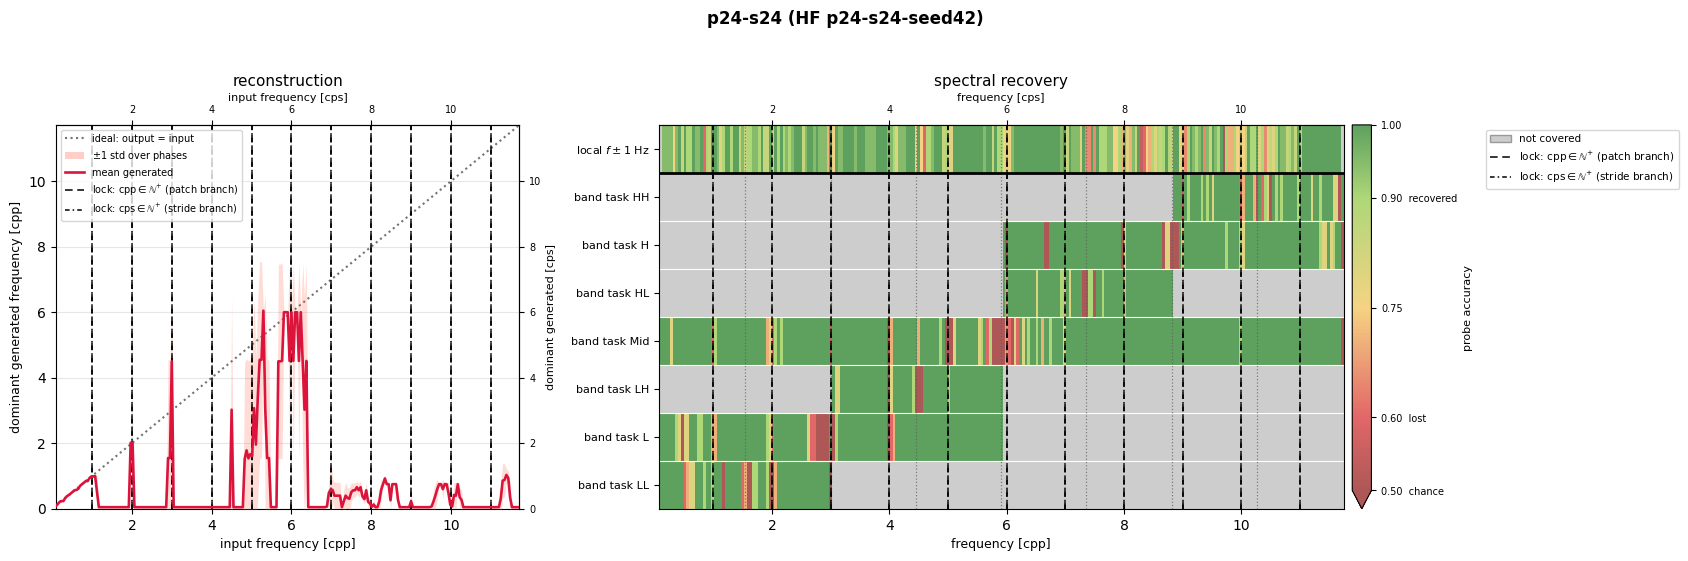

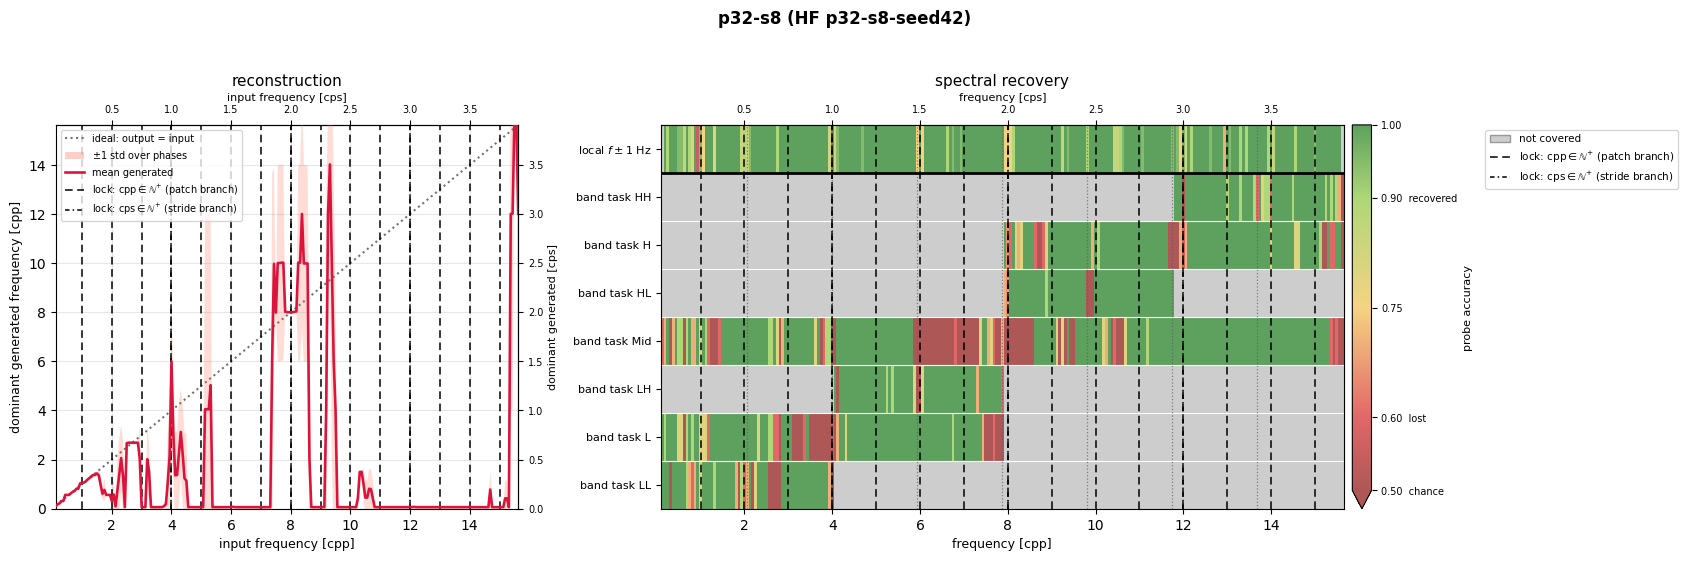

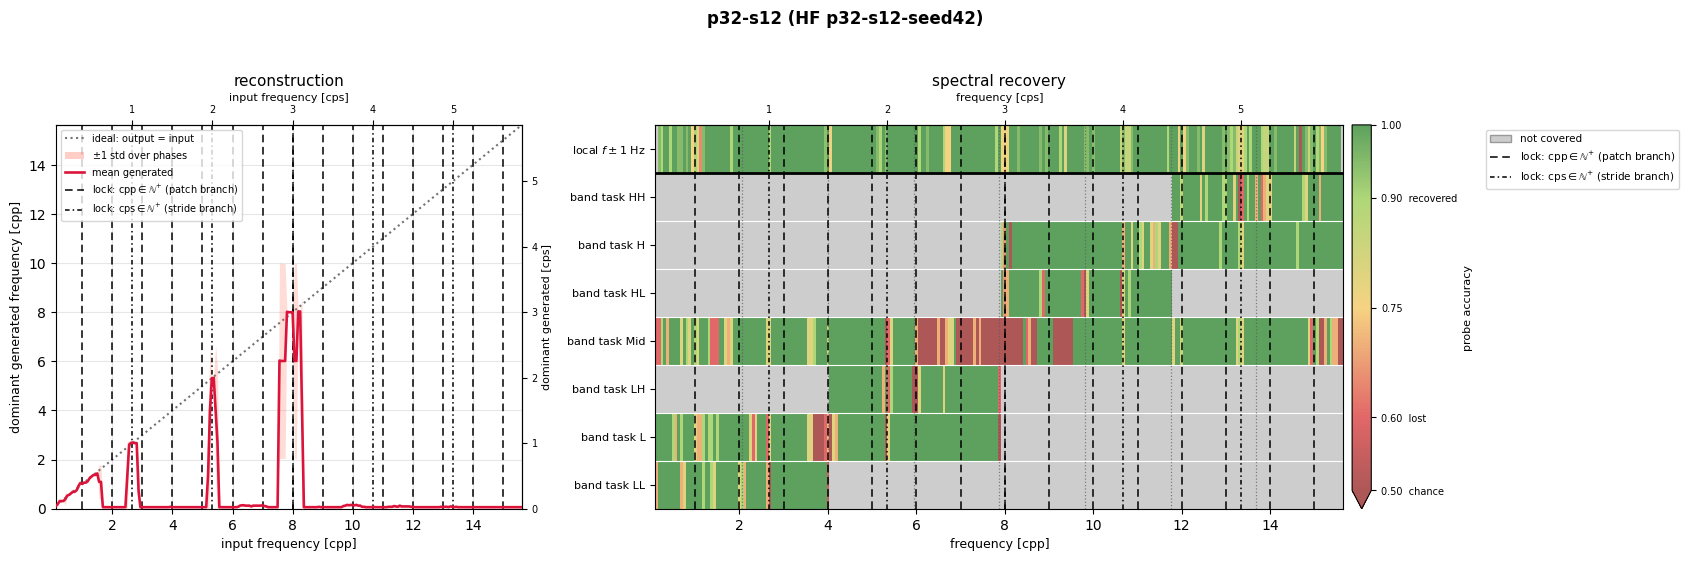

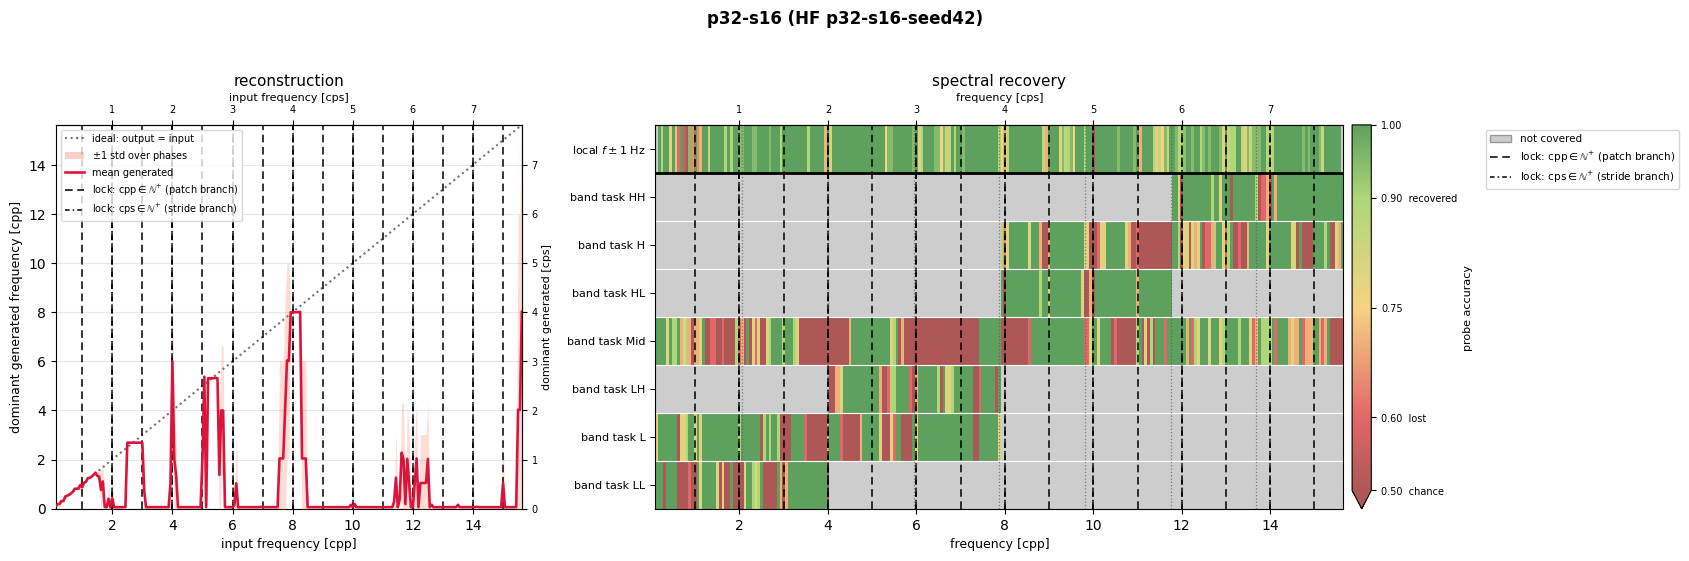

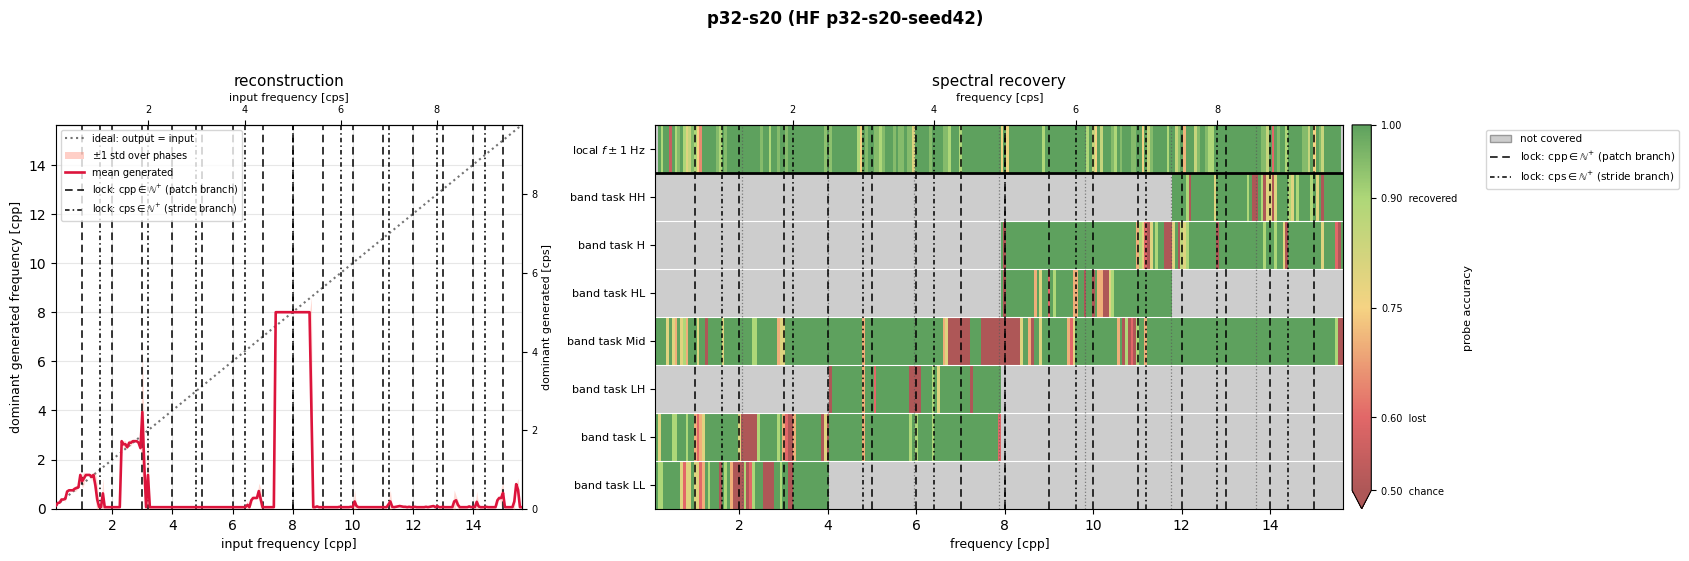

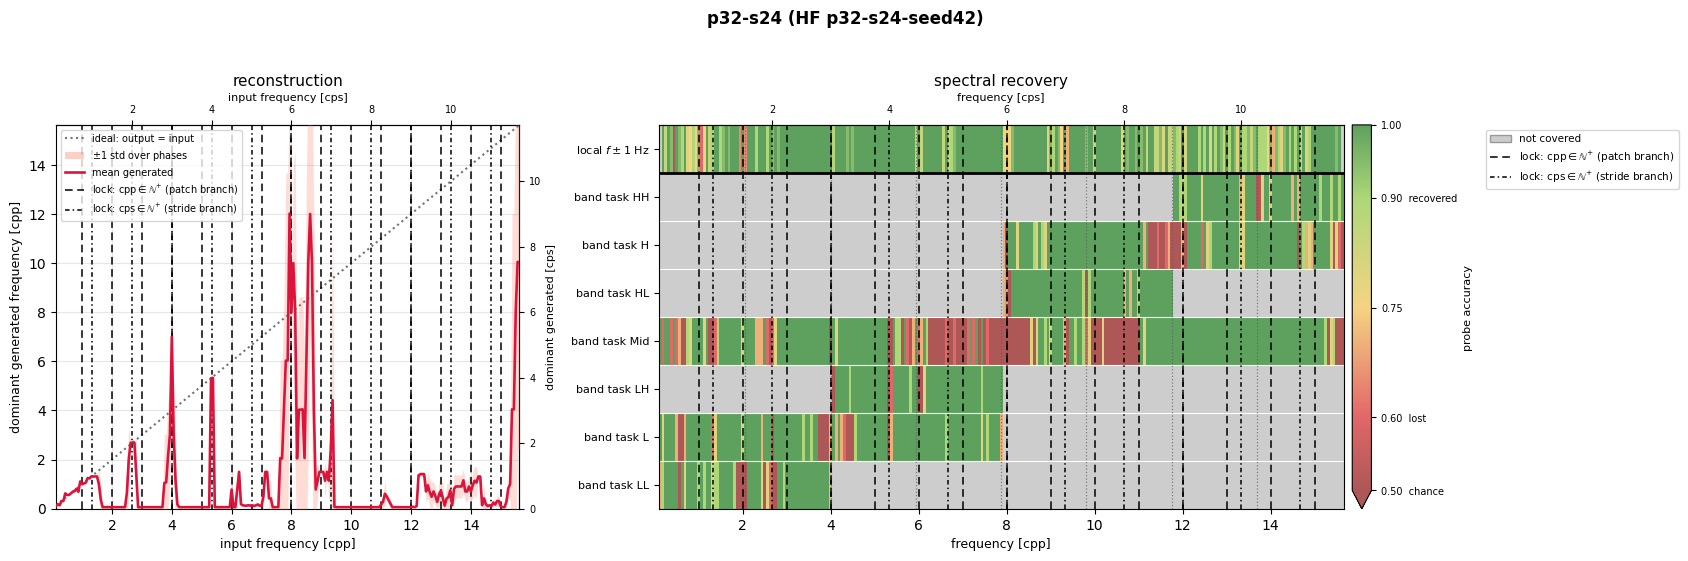

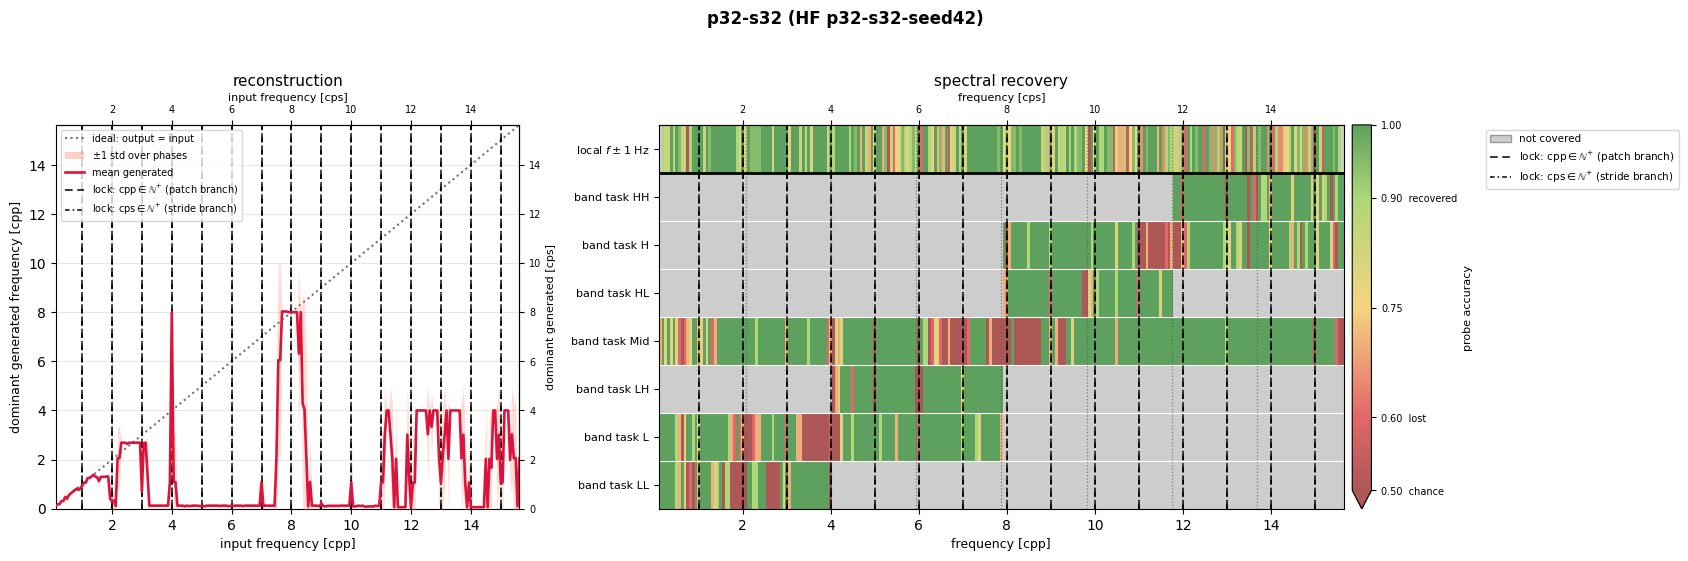

In [6]:
import matplotlib.patheffects as pe
from matplotlib.colors import LinearSegmentedColormap, ListedColormap, Normalize

# --- the recovery colour scale ---------------------------------------------------------------
# Pagani et al. read spectral recovery as three states and the three colours below are that
# reading. What changes here is that the scale BETWEEN them is continuous: a probe at 0.72 is
# drawn between yellow and green instead of being rounded into a bin, so a band that degrades
# gradually reads as a gradient and not as a staircase, and two cells that fell in the same bin
# for very different reasons stop looking identical.
#
# The anchors keep the old thresholds meaningful rather than discarding them. 0.5 is chance on a
# two-class task and is the bottom of the scale; 0.6 and 0.9 were the boundaries of the old
# "lost" and "recovered" bins and still carry their old colours exactly, so a figure drawn with
# this scale can be read against one drawn with the discrete one. Below chance clips to the
# darkest red; a cell with no measurement is grey, which is a different statement from "worst".
ACC_MIN = 0.5
ACC_STOPS = [(0.50, "#8c1010"),      # at or below chance
             (0.60, "#d62728"),      # the old "lost" red
             (0.75, "#f2c14e"),      # the old "partial" yellow
             (0.90, "#8cc63f"),      # the old "recovered" boundary
             (1.00, "#1a7a1a")]      # perfect

# The hues stay bright, the alpha takes the glare off. At full opacity the map reads as alarm
# colours and the eye is pulled to whichever cell is most saturated rather than to the structure;
# at 0.7 over the white page the same hues are still unambiguous and the dark bands at the locked
# frequencies remain the first thing seen. The alpha is baked into the colormap rather than passed
# to pcolormesh so that the colourbar matches the cells exactly. It assumes a white figure
# background, which is what savefig produces here.
ACC_ALPHA = 0.70

_opaque = LinearSegmentedColormap.from_list(
    "recovery_opaque", [((v - ACC_MIN) / (1.0 - ACC_MIN), c) for v, c in ACC_STOPS])
_rgba = _opaque(np.linspace(0.0, 1.0, 256))
_rgba[:, 3] = ACC_ALPHA
CMAP = ListedColormap(_rgba, name="recovery")
CMAP.set_bad((0.72, 0.72, 0.72, ACC_ALPHA))            # not covered: no task reaches this frequency
CMAP.set_under(tuple(_opaque(0.0)[:3]) + (ACC_ALPHA,))  # below chance
NORM = Normalize(vmin=ACC_MIN, vmax=1.0)
CBAR_TICKS  = [0.50, 0.60, 0.75, 0.90, 1.00]
CBAR_LABELS = ["0.50  chance", "0.60  lost", "0.75", "0.90  recovered", "1.00"]

def recovery_mesh(a):
    """Accuracy -> masked array, so a missing measurement draws grey and not as the worst value."""
    return np.ma.masked_invalid(np.asarray(a, dtype=float))

def add_recovery_colourbar(fig, mesh, ax, fraction=0.035):
    cb = fig.colorbar(mesh, ax=ax, pad=0.012, fraction=fraction, extend="min")
    cb.set_ticks(CBAR_TICKS); cb.set_ticklabels(CBAR_LABELS)
    cb.ax.tick_params(labelsize=7)
    cb.set_label("probe accuracy", fontsize=8)
    return cb

# Lock markers have to read on top of the whole scale, so they are drawn as high-contrast lines.
# The two branches get different dashes, as in appendix_reconstruction.ipynb: a patch-branch site
# is an integer number of cycles per patch, a stride-branch site an integer number per stride. On
# a P = S geometry the two coincide and the patch dash is drawn over the stride one.
C_LOCK = "#000000"
CPP_DASH = (0, (5, 3))            # patch branch:  cpp in N+
CPS_DASH = (0, (3, 2, 1, 2))      # stride branch: cps in N+
DASH_LOCK = CPP_DASH              # kept for any cell that still refers to it
LINE_OVER_TOP = 0.22              # the markers run past the top of a strip, where nothing else is
LINE_OVER_BOT = 0.0

FREQ_EDGES = np.r_[FREQS[0] - FREQ_STEP / 2, (FREQS[:-1] + FREQS[1:]) / 2,
                   FREQS[-1] + FREQ_STEP / 2]          # cell edges of the sweep, in Hz


def to_cpp(f, P):
    """Section 2: cycles per patch, cpp = f P / fs."""
    return np.asarray(f, dtype=float) * P / pl.FS


def draw_locks(ax, P, S, lw=1.1, alpha=1.0, zorder=3):
    """Stride-branch sites first, patch-branch sites over them, both in cpp."""
    for freqs, style in ((pl.stride_locks(S), CPS_DASH), (pl.patch_nulls(P), CPP_DASH)):
        for f in freqs:
            ax.axvline(f * P / pl.FS, color=C_LOCK, lw=lw, ls=style, alpha=alpha, zorder=zorder)


def cps_axes(ax, P, S, xlabel="input frequency", output=False, fontsize=8):
    """Primary axis in cpp; secondary axes in cps = cpp * S / P (top, and right for the output)."""
    functions = (lambda v: v * S / P, lambda v: v * P / S)
    sec = ax.secondary_xaxis("top", functions=functions)
    sec.set_xlabel(f"{xlabel} [cps]", fontsize=fontsize, labelpad=3)
    sec.tick_params(labelsize=fontsize - 1)
    if xlabel:
        ax.set_xlabel(f"{xlabel} [cpp]", fontsize=fontsize + 1)
    if output:
        sec_y = ax.secondary_yaxis("right", functions=functions)
        sec_y.set_ylabel("dominant generated [cps]", fontsize=fontsize, labelpad=3)
        sec_y.tick_params(labelsize=fontsize - 1)


LOCK_HANDLES = [Line2D([0], [0], color=C_LOCK, lw=1.1, ls=CPP_DASH,
                       label=r"lock: $\mathrm{cpp}\in\mathbb{N}^{+}$ (patch branch)"),
                Line2D([0], [0], color=C_LOCK, lw=1.1, ls=CPS_DASH,
                       label=r"lock: $\mathrm{cps}\in\mathbb{N}^{+}$ (stride branch)")]
# The colour scale is carried by the colourbar, so the legend states only what the colourbar
# cannot: the grey of an unmeasured cell, and the two kinds of lock marker.
LEGEND = [Patch(fc=(0.72, 0.72, 0.72, ACC_ALPHA), ec="0.6", label="not covered")] + LOCK_HANDLES
RECON_HANDLES = [Line2D([0], [0], ls=":", color="0.45", lw=1.5, label="ideal: output = input"),
                 Patch(fc="tomato", alpha=.30, label="$\\pm$1 std over phases"),
                 Line2D([0], [0], color="crimson", lw=1.9, label="mean generated")] + LOCK_HANDLES


def display_order(results):
    """Panels read left-to-right by patch size, then stride."""
    return sorted(results, key=lambda t: (results[t]["P"], results[t]["S"]))


# --- every figure this notebook draws is written to OUT, one file per figure ------------------
SAVED = []

def save(fig, name, dpi=300):
    path = OUT / name
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    SAVED.append(name)
    return path


# --- the two panels, each drawable on its own axes so each can also be saved on its own --------
def draw_reconstruction(ax, r, legend=True, fontsize=8):
    """Dominant generated frequency against the input, both in cpp of this geometry."""
    P, S, rc = r["P"], r["S"], r["recon"]
    band = to_cpp(pl.BAND, P)
    freq, mean = to_cpp(rc["freq"], P), to_cpp(rc["mean"], P)
    std = to_cpp(rc["std"].fillna(0), P)
    ax.plot(band, band, ls=":", color="0.45", lw=1.5, zorder=2)
    ax.fill_between(freq, mean - std, mean + std, color="tomato", alpha=.22, lw=0, zorder=3)
    ax.plot(freq, mean, color="crimson", lw=1.9, zorder=4)
    draw_locks(ax, P, S)
    ax.set_xlim(*band); ax.set_ylim(0, band[1]); ax.grid(alpha=.3)
    ax.set_ylabel("dominant generated frequency [cpp]", fontsize=fontsize + 1)
    cps_axes(ax, P, S, output=True, fontsize=fontsize)
    if legend:
        ax.legend(handles=RECON_HANDLES, loc="upper left", fontsize=fontsize - 1)


def draw_spectral(ax, r, fig, colourbar=True, legend=True, cb_fraction=0.035, fontsize=8):
    """Probe accuracy per swept frequency and task, frequency axis in cpp of this geometry."""
    P, S = r["P"], r["S"]
    acc, labels = r["acc"], r["row_labels"]
    mesh = ax.pcolormesh(to_cpp(FREQ_EDGES, P), np.arange(len(labels) + 1),
                         recovery_mesh(acc), cmap=CMAP, norm=NORM,
                         shading="flat", edgecolors="none", rasterized=True)
    for y in range(1, len(labels)):                    # thin separators instead of a cell grid,
        ax.axhline(y, color="white", lw=0.8)           # which a gradient cannot afford
    draw_locks(ax, P, S)
    for (_n, _lo, _hi, bnd) in pl.BAND_TASKS:          # task boundaries, dotted grey
        ax.axvline(bnd * P / pl.FS, color="0.35", lw=.9, ls=":", alpha=.7)
    ax.axhline(len(labels) - 1, color="k", lw=2)       # the trustworthy row, separated
    ax.set_yticks(np.arange(len(labels)) + 0.5); ax.set_yticklabels(labels, fontsize=fontsize)
    ax.set_xlim(to_cpp(FREQ_EDGES[0], P), to_cpp(FREQ_EDGES[-1], P))
    cps_axes(ax, P, S, xlabel="frequency", fontsize=fontsize)
    if colourbar:
        add_recovery_colourbar(fig, mesh, ax, fraction=cb_fraction)
    if legend:
        ax.legend(handles=LEGEND, bbox_to_anchor=(1.20, 1), loc="upper left", fontsize=7.5)
    return mesh


for tag in display_order(RESULTS):
    r = RESULTS[tag]

    # --- the pair, side by side: what the model outputs next to what it still knows ------------
    fig, (a0, a1) = plt.subplots(1, 2, figsize=(17, 5.4),
                                 gridspec_kw={"width_ratios": [1, 1.55]})
    draw_reconstruction(a0, r); a0.set_title("reconstruction", fontsize=11, pad=28)
    draw_spectral(a1, r, fig);  a1.set_title("spectral recovery", fontsize=11, pad=28)
    fig.suptitle(r["label"], fontweight="bold", y=1.03)
    fig.tight_layout()
    save(fig, f"FIG_{tag}.png")
    plt.show()

    # --- and each panel again on its own, so either can be used as a standalone figure ---------
    f1, ax = plt.subplots(figsize=(7.0, 5.4))
    draw_reconstruction(ax, r)
    ax.set_title(f"{r['label']} — reconstruction", fontsize=11, pad=28)
    f1.tight_layout(); save(f1, f"FIG_{tag}_reconstruction.png"); plt.close(f1)

    f2, ax = plt.subplots(figsize=(11.5, 5.2))
    draw_spectral(ax, r, f2, cb_fraction=0.030)
    ax.set_title(f"{r['label']} — spectral recovery", fontsize=11, pad=28)
    f2.tight_layout(); save(f2, f"FIG_{tag}_spectral_recovery.png"); plt.close(f2)


## 3, All geometries side by side

The per-geometry figures above answer *what does this model do*. These two answer the question the
sweep exists for: **does the behaviour move when the tokenisation geometry changes?** The predicted
sites are drawn on every panel, so a dip that follows its own geometry's markers from panel to panel
is the phenomenon, and one that stays put across geometries is not.

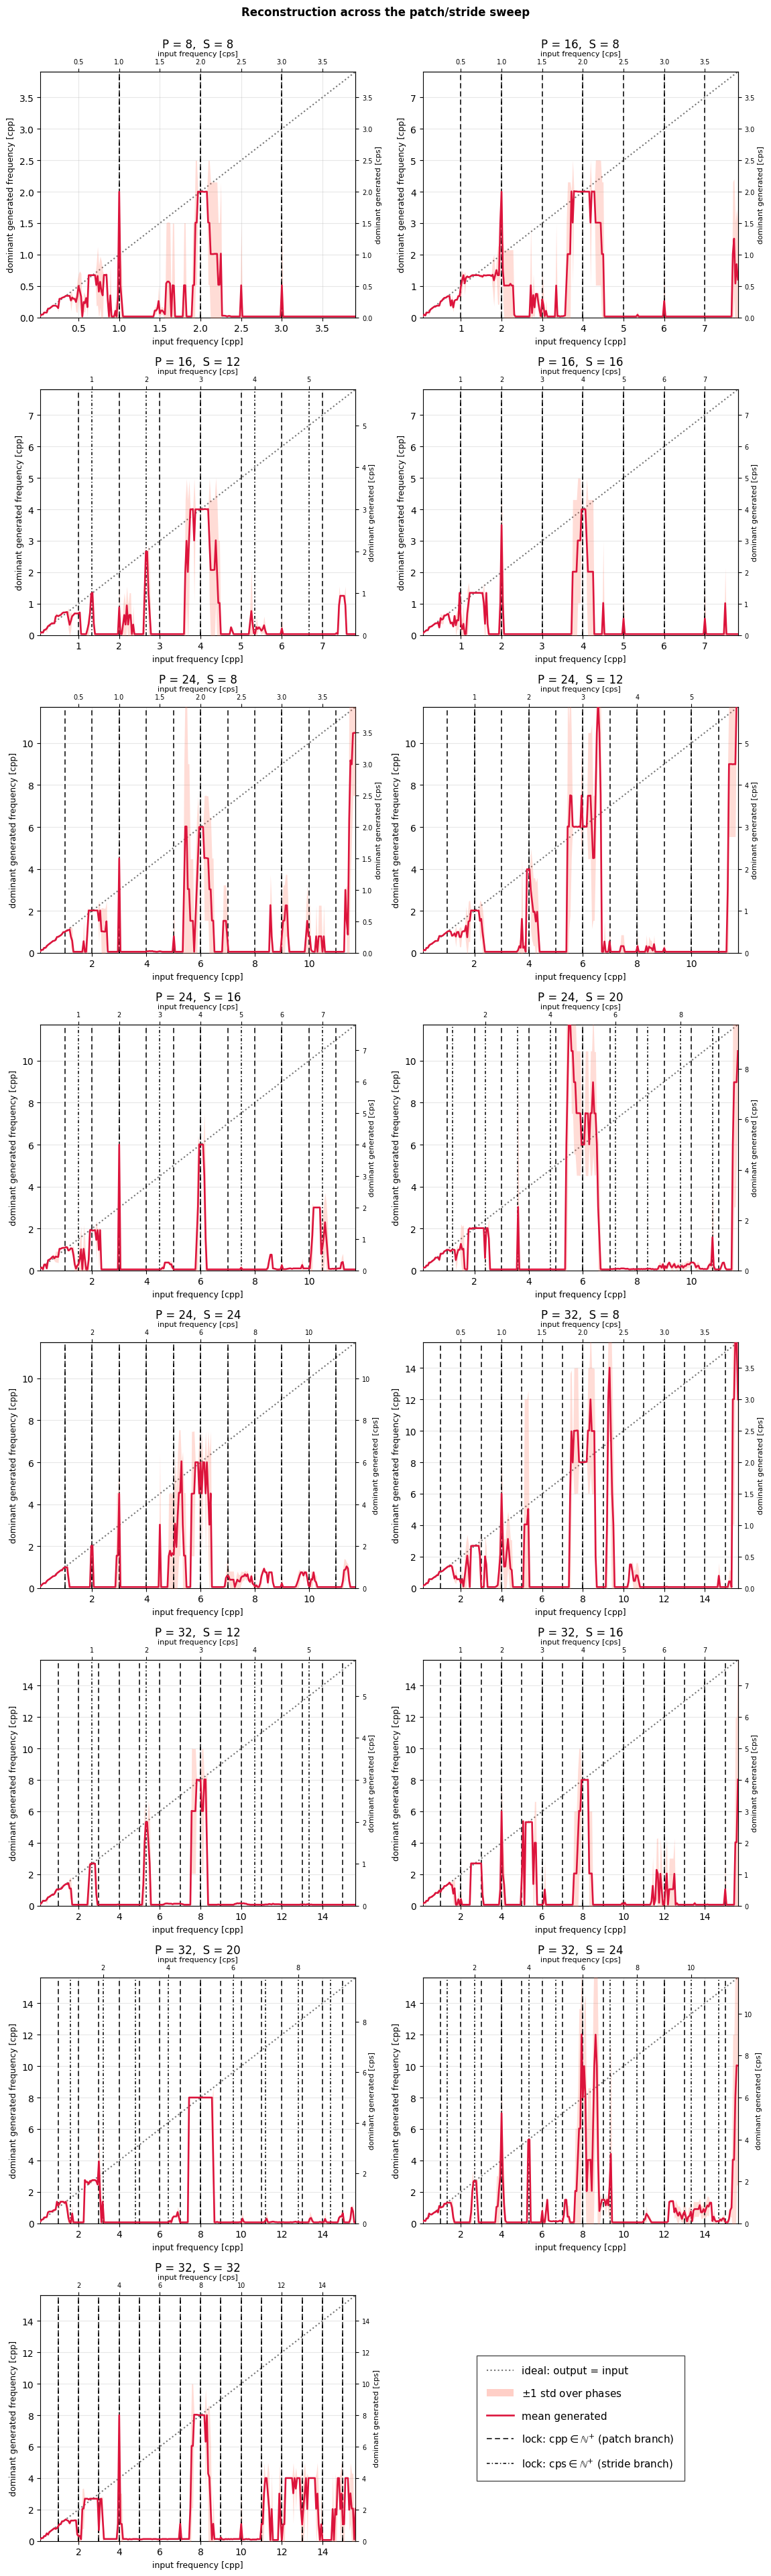

In [7]:
import math
tags_r = display_order(RESULTS)
ncols = 2
nrows = math.ceil(len(tags_r) / ncols)
# Each panel carries its own geometry's units, so the axes are not shared.
fig, axgrid = plt.subplots(nrows, ncols, figsize=(5.8 * ncols, 4.8 * nrows), squeeze=False)
flat = axgrid.ravel()
for ax, t in zip(flat, tags_r):
    r = RESULTS[t]
    draw_reconstruction(ax, r, legend=False)
    ax.set_title(f"P = {r['P']},  S = {r['S']}", fontsize=12, pad=26)
# With an odd number of geometries the grid leaves one slot empty: put the legend there rather
# than stealing height from the panels.
spare = list(flat[len(tags_r):])
for ax in spare:
    ax.axis("off")
if spare:
    spare[0].legend(handles=RECON_HANDLES, loc="center", frameon=True, fancybox=False,
                    edgecolor="0.3", framealpha=1, fontsize=11,
                    handlelength=2.6, labelspacing=1.1, borderpad=1.0)
else:
    fig.legend(handles=RECON_HANDLES, loc="lower center", bbox_to_anchor=(0.5, -0.04),
               ncol=5, frameon=True, fancybox=False, edgecolor="0.3", framealpha=1,
               fontsize=10, borderpad=0.7)
fig.suptitle("Reconstruction across the patch/stride sweep", fontweight="bold", y=1.0)
fig.tight_layout()
save(fig, "FIG_ALL_reconstruction.png")
plt.show()


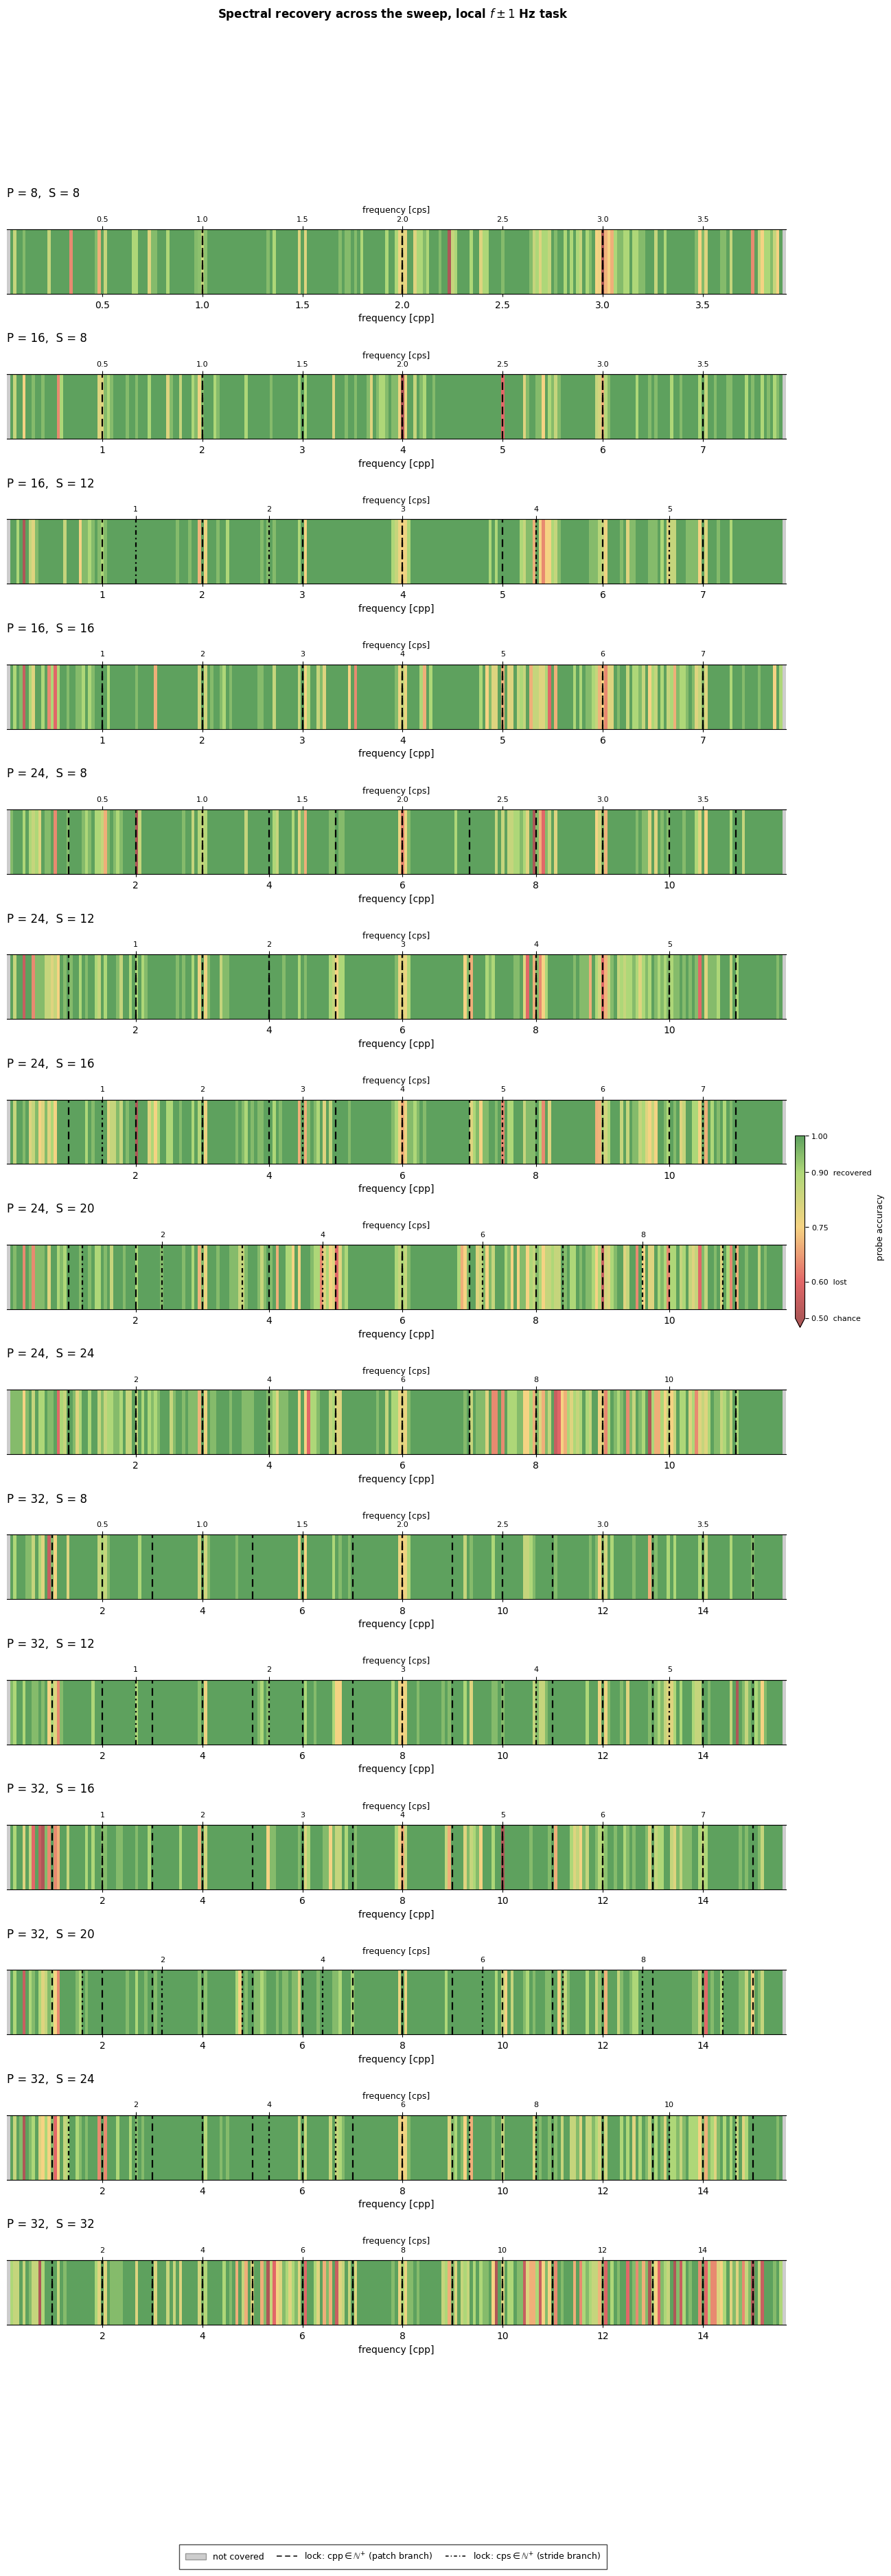

,model,P,S,spectral_RMSE_Hz,pct_on_diagonal,pct_recovered,pct_lost
0,p8-s8,8,8,137.7,12.9,85.1,0.8
1,p16-s8,16,8,133.8,13.3,90.0,0.4
2,p16-s12,16,12,135.6,9.6,88.0,0.4
3,p16-s16,16,16,139.8,11.6,79.5,0.4
4,p24-s8,24,8,131.1,13.3,84.7,0.8
5,p24-s12,24,12,129.2,13.3,84.7,0.4
6,p24-s16,24,16,138.3,7.2,81.9,0.4
7,p24-s20,24,20,133.3,11.2,76.3,0.4
8,p24-s24,24,24,135.7,10.8,74.7,0.8
9,p32-s8,32,8,131.8,13.3,90.8,0.4



47 figures written to c:\Users\bonio\dev\patchAliasing\notebooks\_run\full\pagani
    FIG_p8-s8.png
    FIG_p8-s8_reconstruction.png
    FIG_p8-s8_spectral_recovery.png
    FIG_p16-s8.png
    FIG_p16-s8_reconstruction.png
    FIG_p16-s8_spectral_recovery.png
    FIG_p16-s12.png
    FIG_p16-s12_reconstruction.png
    FIG_p16-s12_spectral_recovery.png
    FIG_p16-s16.png
    FIG_p16-s16_reconstruction.png
    FIG_p16-s16_spectral_recovery.png
    FIG_p24-s8.png
    FIG_p24-s8_reconstruction.png
    FIG_p24-s8_spectral_recovery.png
    FIG_p24-s12.png
    FIG_p24-s12_reconstruction.png
    FIG_p24-s12_spectral_recovery.png
    FIG_p24-s16.png
    FIG_p24-s16_reconstruction.png
    FIG_p24-s16_spectral_recovery.png
    FIG_p24-s20.png
    FIG_p24-s20_reconstruction.png
    FIG_p24-s20_spectral_recovery.png
    FIG_p24-s24.png
    FIG_p24-s24_reconstruction.png
    FIG_p24-s24_spectral_recovery.png
    FIG_p32-s8.png
    FIG_p32-s8_reconstruction.png
    FIG_p32-s8_spectral_recovery.png
  

In [8]:
# One panel per geometry, sharing a single legend and colour scale: each carries its own
# frequency axis, so a band can be read without tracing across to another panel's ticks.
tags = display_order(RESULTS)
fig, axes = plt.subplots(len(tags), 1, figsize=(15, 2.45 * len(tags) + 1.4), squeeze=False)
axes = axes[:, 0]
fig.subplots_adjust(hspace=1.25, top=0.90, bottom=0.10)

mesh = None
for ax, t in zip(axes, tags):
    r = RESULTS[t]
    P, S = r["P"], r["S"]
    mesh = ax.pcolormesh(to_cpp(FREQ_EDGES, P), np.array([0, 1]),
                         recovery_mesh(r["acc"][-1])[None, :],
                         cmap=CMAP, norm=NORM, shading="flat", edgecolors="none",
                         rasterized=True, zorder=2)
    for freqs, style in ((pl.stride_locks(S), CPS_DASH), (pl.patch_nulls(P), CPP_DASH)):
        for f in freqs:
            ax.axvline(f * P / pl.FS, color=C_LOCK, lw=1.6, ls=style, zorder=4)
    ax.set_xlim(to_cpp(FREQ_EDGES[0], P), to_cpp(FREQ_EDGES[-1], P))
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    ax.set_title(f"P = {P},  S = {S}", fontsize=12, pad=34, loc="left")
    cps_axes(ax, P, S, xlabel="frequency", fontsize=9)
    ax.tick_params(axis="x", length=3, pad=4)
    for side in ("right", "left"):
        ax.spines[side].set_visible(False)

cb = fig.colorbar(mesh, ax=axes.tolist(), pad=0.012, fraction=0.012, extend="min")
cb.set_ticks(CBAR_TICKS); cb.set_ticklabels(CBAR_LABELS)
cb.ax.tick_params(labelsize=8); cb.set_label("probe accuracy", fontsize=9)
fig.suptitle("Spectral recovery across the sweep, local $f\\pm1$ Hz task",
             fontweight="bold", y=0.985)
fig.legend(handles=LEGEND, loc="lower center", bbox_to_anchor=(0.5, 0.005),
           ncol=6, frameon=True, fancybox=False, edgecolor="0.3", framealpha=1,
           fontsize=9, handlelength=2.4, columnspacing=1.5, borderpad=0.7)
save(fig, "FIG_ALL_spectral_recovery.png")
plt.show()

summary = pd.DataFrame([
    dict(model=t,
         P=RESULTS[t]["P"], S=RESULTS[t]["S"],
         spectral_RMSE_Hz=round(float(np.sqrt(np.mean(
             (RESULTS[t]["recon"]["mean"] - RESULTS[t]["recon"]["freq"]) ** 2))), 1),
         pct_on_diagonal=round(float(np.mean(
             np.abs(RESULTS[t]["recon"]["mean"] - RESULTS[t]["recon"]["freq"]) <= 2.0)) * 100, 1),
         pct_recovered=round(float(np.nanmean(RESULTS[t]["acc"][-1] >= 0.9)) * 100, 1),
         pct_lost=round(float(np.nanmean(RESULTS[t]["acc"][-1] < 0.6)) * 100, 1))
    for t in display_order(RESULTS)])
summary.to_parquet(OUT / "reconstruction_summary.parquet", index=False)
display(summary)

# --- what was written -------------------------------------------------------------------------
print(f"\n{len(SAVED)} figures written to {OUT}")
for name in SAVED:
    print("   ", name)

In [9]:
# --- attractors: the output values that many off-diagonal inputs collapse onto ---------------
# The figures suggest that the rollout returns a few output frequencies for many different inputs.
# This table puts numbers on that reading instead of leaving it to the eye: for each geometry it
# keeps the inputs whose mean dominant output is more than 2 Hz from the input and not in the
# slow bins (above 2 Hz), and counts how many of them land on each output bin. An output bin
# counts as a site when it lies within half a bin (0.5 Hz) of a patch-branch (cpp integer) or
# stride-branch (cps integer) candidate of that geometry. Everything is reported in cpp and cps.
ATTRACTOR_MIN_INPUTS = 5
rows = []
for t in display_order(RESULTS):
    r = RESULTS[t]; P, S = r["P"], r["S"]; rc = r["recon"]
    off = rc[(np.abs(rc["mean"] - rc["freq"]) > 2.0) & (rc["mean"] > 2.0)]
    counts = off["mean"].round().value_counts()
    sites = np.r_[pl.patch_nulls(P), pl.stride_locks(S)]
    for f_out, n in counts[counts >= ATTRACTOR_MIN_INPUTS].items():
        rows.append(dict(model=t, P=P, S=S, n_inputs=int(n),
                         out_cpp=round(f_out * P / pl.FS, 3), out_cps=round(f_out * S / pl.FS, 3),
                         is_site=bool(np.min(np.abs(sites - f_out)) <= 0.5) if len(sites) else False,
                         inputs_cpp=f"{off.freq[off['mean'].round() == f_out].min() * P / pl.FS:.2f}"
                                    f"-{off.freq[off['mean'].round() == f_out].max() * P / pl.FS:.2f}"))
ATTRACTORS = pd.DataFrame(rows).sort_values(["P", "S", "n_inputs"], ascending=[True, True, False])
ATTRACTORS.to_csv(OUT / "reconstruction_attractors.csv", index=False)
display(ATTRACTORS)


,model,P,S,n_inputs,out_cpp,out_cps,is_site,inputs_cpp
0,p8-s8,8,8,10,0.516,0.516,False,0.72-3.00
1,p8-s8,8,8,5,0.344,0.344,False,0.39-0.98
2,p8-s8,8,8,5,0.109,0.109,False,0.95-1.53
3,p16-s8,16,8,13,4.000,2.000,True,2.00-4.28
4,p16-s8,16,8,11,1.344,0.672,False,1.06-1.94
...,...,...,...,...,...,...,...,...
67,p32-s32,32,32,7,2.688,2.688,False,2.31-3.12
68,p32-s32,32,32,7,8.000,8.000,True,4.00-8.31
69,p32-s32,32,32,7,2.000,2.000,True,11.38-15.31
70,p32-s32,32,32,6,1.125,1.125,False,1.56-11.00


## How to read the two together

The reconstruction panel says what the model *outputs*; the recovery panel says what it still
*knows*. They can disagree, and each combination means something different:

* **on the diagonal and green**, the frequency is represented and rebuilt;
* **off the diagonal but green**, the information survives in the representation and is lost at the
  projection, which points at the head rather than at the tokenisation;
* **red**, the frequency is not recoverable from the representation at all, which is the stronger
  claim and the one structural aliasing predicts at the locked frequencies.

The colour scale is continuous between those readings, so it also carries what a three-state map
cannot: how *far* a column has moved. A column at $0.72$ sits between yellow and green and is a
partial loss; one at $0.52$ is at the dark end and is indistinguishable from chance. **Grey is not
the bottom of the scale**: it means no task covers that frequency, which is a statement about the
design and not about the model.

The dashed markers are the frequencies the geometry predicts as locked, $\mathcal{F}_{lock}$: the
union of the patch nulls $k f_s/P$ and the stride locks $c f_s/S$. Where the two grids are dense the
tick *labels* are thinned so they do not print on top of one another, but every predicted lock is
still drawn. On any $P=S$ geometry the two families coincide, and only the $S \nmid P$
configurations separate them.
